<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/Basic_Convolutional_Network_1_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

retreattechnology_assignment01deeplearning_path = kagglehub.dataset_download('retreattechnology/assignment01deeplearning')

print('Data source import complete.')


When you download or use it in Kaggle/Colab, you will see:
seg_train/
seg_test/
seg_pred/   (sometimes present)

1. Training Data → seg_train
This is your main dataset used to train the model.

Contains images in 6 categories:

i) buildings
ii) forest
iii) glacier
iv) mountain
v) sea
vi) street

Folder structure:
seg_train/
    buildings/
    forest/
    glacier/
    mountain/
    sea/
    street/

Each folder contains images of that class.

Purpose:
Used to teach the model
Model learns patterns (edges, shapes, textures)

2. Test Data → seg_test

This is NOT validation, but many students confuse it.

seg_test/
    buildings/
    forest/
    glacier/
    mountain/
    sea/
    street/

Purpose:
Used after training is complete
Measures final performance (accuracy)

3. Validation Data → ❗ NOT PROVIDED DIRECTLY

Important point 👇
👉 The dataset does NOT have a separate validation folder

So you must create validation data manually from seg_train

How to Create Validation Split

Typically:

80% → Training
20% → Validation

What This Code Does (Simple Understanding)
Reads images from:
seg_train/
   buildings/
   forest/
   glacier/
   mountain/
   sea/
   street/
Automatically:
Assigns labels (one-hot encoding)
Resizes images to 150×150
Splits into:
80% training
20% validation

In [ ]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# 2. Set Dataset Path
#train_dir = "/kaggle/input/intel-image-classification/seg_train/seg_train"
#test_dir= "/kaggle/input/intel-image-classification/seg_test/seg_test"
train_dir = "/kaggle/input/datasets/retreattechnology/assignment01deeplearning/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/assignment01deeplearning/Intel_Image_Classification_Dataset/seg_test"


In [ ]:
# 3. Data Preprocessing (Train + Validation Split)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [ ]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [ ]:
#5. Build CNN Model

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer (6 classes)
model.add(layers.Dense(6, activation='softmax'))

In [ ]:
#6. Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 7. Train Model
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step - accuracy: 0.4742 - loss: 1.3016 - val_accuracy: 0.6551 - val_loss: 0.8577
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.6786 - loss: 0.8496 - val_accuracy: 0.7628 - val_loss: 0.6606
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.7426 - loss: 0.6949 - val_accuracy: 0.7921 - val_loss: 0.6012
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.7900 - loss: 0.5817 - val_accuracy: 0.8195 - val_loss: 0.5222
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8250 - loss: 0.4896 - val_accuracy: 0.8110 - val_loss: 0.5734
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.8444 - loss: 0.4355 - val_accuracy: 0.8146 - val_loss: 0.5644
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.8778 - loss: 0.3648 - val_accuracy: 0.8338 - val_loss: 0.5551
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.8931 - loss: 0.2962 -

In [ ]:
# 8. Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.8006 - loss: 0.7978
Test Accuracy: 0.8113333582878113


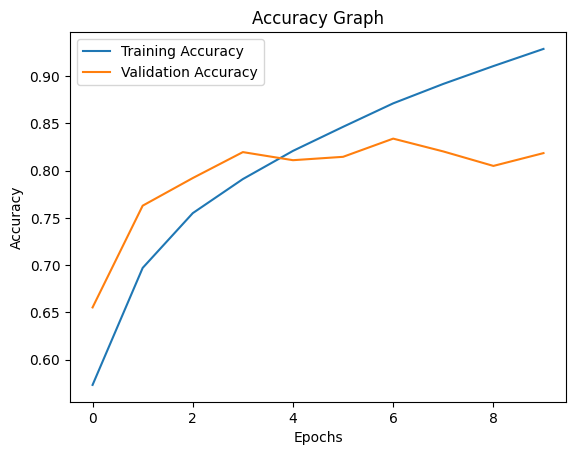

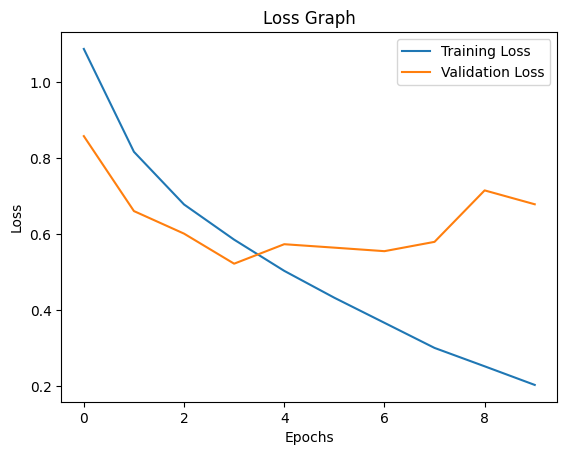

In [ ]:
# 9. Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

What you just built:
CNN with 3 convolution layers
ReLU activation
MaxPooling
Dropout (prevents overfitting)
Softmax output (6 classes)

Tips to Improve Accuracy

You can upgrade this model easily:

👉 Add data augmentation

ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

#👉 Increase epochs (20–30)
#👉 Use pretrained models (Transfer Learning like ResNet)

Final Understanding

Pipeline you implemented:

Dataset → Train Split → CNN → Validation → Test → Graphs